# Этап 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Импорт библиотек

In [72]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from scipy.fft import fft
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import joblib

Считывание данных из подготовленного файла

In [73]:
data = pd.read_csv('data.csv', header=None, names=['t', 'a', 'klass'])

Считывание данных для обучение модели

In [74]:
train_data = pd.read_csv('train_data.csv', names=['t', 'a', 'klass'])

In [75]:
def extract_features(segment):
    """Извлекает признаки, которые различают 6 классов."""
    N = len(segment)
    features = {}

    # Средний уровень сигнала в сегменте
    seg_mean = np.mean(segment)
    # СКО в сигнала в сегменте
    seg_std = np.std(segment) + 1e-10
    
    # Размах сигнала
    features['norm_range'] = (np.max(segment) - np.min(segment)) / seg_std
    
    # Максимальная производная
    derivative = np.diff(segment)
    features['max_derivative_norm'] = np.max(np.abs(derivative)) / seg_std
    
    # Стандартное отклонение нормализованного сигнала = 1 по определению,
    # но используем отношение max/min отклонения от среднего
    features['max_deviation_norm'] = max(
        np.max(segment) - seg_mean,
        seg_mean - np.min(segment)
    ) / seg_std
    
    # Доля точек, сильно отклоняющихся от среднего
    threshold_low = seg_mean - 1.5 * seg_std
    threshold_high = seg_mean + 1.5 * seg_std
    
    low_points = np.sum(segment < threshold_low) / N
    high_points = np.sum(segment > threshold_high) / N
    
    # Процент точек, сильно ниже среднего
    features['low_points_ratio'] = low_points
    # Процент точек, сильно выше среднего
    features['high_points_ratio'] = high_points
    # Процент "аномальных" точек
    features['extreme_points_ratio'] = low_points + high_points

    # Нормализуем сигнал с помощью Z-масштабирования
    seg_norm = (segment - seg_mean) / seg_std 
    
    yf = fft(seg_norm)
    spectrum = np.abs(yf[:N // 2 + 1])
    harmonics = np.arange(N // 2 + 1)
    max_harmonic = N // 2
    
    # Энергия в полосах
    low_threshold = max(1, int(max_harmonic * 0.1))
    mid_threshold = int(max_harmonic * 0.4)
    
    low_mask = (harmonics >= 1) & (harmonics < low_threshold)
    mid_mask = (harmonics >= low_threshold) & (harmonics < mid_threshold)
    high_mask = harmonics >= mid_threshold
    
    low_energy = np.sum(spectrum[low_mask] ** 2)
    mid_energy = np.sum(spectrum[mid_mask] ** 2)
    high_energy = np.sum(spectrum[high_mask] ** 2)
    total_energy = np.sum(spectrum[1:] ** 2) + 1e-10
    
    # Отношение ВЧ к НЧ
    features['high_to_low_ratio'] = (high_energy + 1e-10) / (low_energy + 1e-10)
    
    # Доля энергии на высоких частотах
    features['high_freq_ratio'] = high_energy / total_energy
    
    # Спектральный центроид
    features['spectral_centroid'] = np.sum(harmonics[1:] * spectrum[1:]) / total_energy / max_harmonic
    
    # Выделение огибающей для замера её наклона
    if N >= 21:
        envelope = savgol_filter(segment, window_length=21, polyorder=3)
    else:
        envelope = segment.copy()
    
    t = np.arange(N)
    slope = np.polyfit(t, envelope, 1)[0]
    features['envelope_slope_norm'] = slope / seg_std
    
    # Размах огибающей
    features['envelope_range_norm'] = (np.max(envelope) - np.min(envelope)) / seg_std

    # Ассиметрия спектра
    half = len(spectrum) // 2
    first_half_energy = np.sum(spectrum[1:half] ** 2)
    second_half_energy = np.sum(spectrum[half:] ** 2)
    features['spectrum_asymmetry'] = (first_half_energy - second_half_energy) / (total_energy + 1e-10)
    
    return features

Подготовка тренировочных данных

In [76]:
SEGMENT_LENGTH = 100
train_segments = []
train_labels = []

for i in range(0, len(train_data) - SEGMENT_LENGTH + 1, SEGMENT_LENGTH):
    segment = train_data['a'].iloc[i:i+SEGMENT_LENGTH].values
    label = train_data['klass'].iloc[i]
    train_segments.append(segment)
    train_labels.append(label)

X = np.array([list(extract_features(seg).values()) for seg in train_segments])
y = np.array(train_labels)

Подготовка данных для предсказания

In [77]:
TEST_SEGMENT_LENGTH = 100
test_segments = []
test_labels = []

for i in range(0, len(data) - TEST_SEGMENT_LENGTH + 1, TEST_SEGMENT_LENGTH):
    segment = data['a'].iloc[i:i+TEST_SEGMENT_LENGTH].values
    label = data['klass'].iloc[i]
    test_segments.append(segment)
    test_labels.append(label)

X_test = np.array([list(extract_features(seg).values()) for seg in test_segments])
y_test = np.array(test_labels)

Обучение модели

In [78]:
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)
#
#param_grid = {
#    'n_estimators': [100, 200, 300, 500],
#    'max_depth': [10, 15, 20, None],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 4],
#    'max_features': ['sqrt', 'log2', None],
#}
#
#rf = RandomForestClassifier(random_state=42, class_weight='balanced')
#
#grid_search = GridSearchCV(
#    estimator=rf,
#    param_grid=param_grid,
#    cv=5,
#    scoring='accuracy',
#    n_jobs=-1,
#    verbose=1
#)
#
#grid_search.fit(X_scaled, y)
#
#best_model = grid_search.best_estimator_
#y_pred = best_model.predict(X_test_scaled)
#accuracy = np.mean(y_pred == y_test)

In [79]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=15, min_samples_leaf=2, class_weight='balanced')
model.fit(X_scaled, y)

y_pred = model.predict(X_test_scaled)
accuracy = np.mean(y_pred == y_test)

In [80]:
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [81]:
accuracy

np.float64(1.0)

In [82]:
y_pred

array([1, 2, 1, 3, 1, 4, 1, 5, 1, 6])

Изобразим предсказание на графике

In [83]:
colors = {
    1: 'green',
    2: 'cyan',    
    3: 'orange',
    4: 'red',    
    5: 'blue',      
    6: 'purple'
}

In [84]:
class_names = {
    1: 'стабильный',
    2: 'плавный рост',
    3: 'плавное падение',
    4: 'резкий обвал',
    5: 'резкий подъем',
    6: 'обвал + подъем'
}

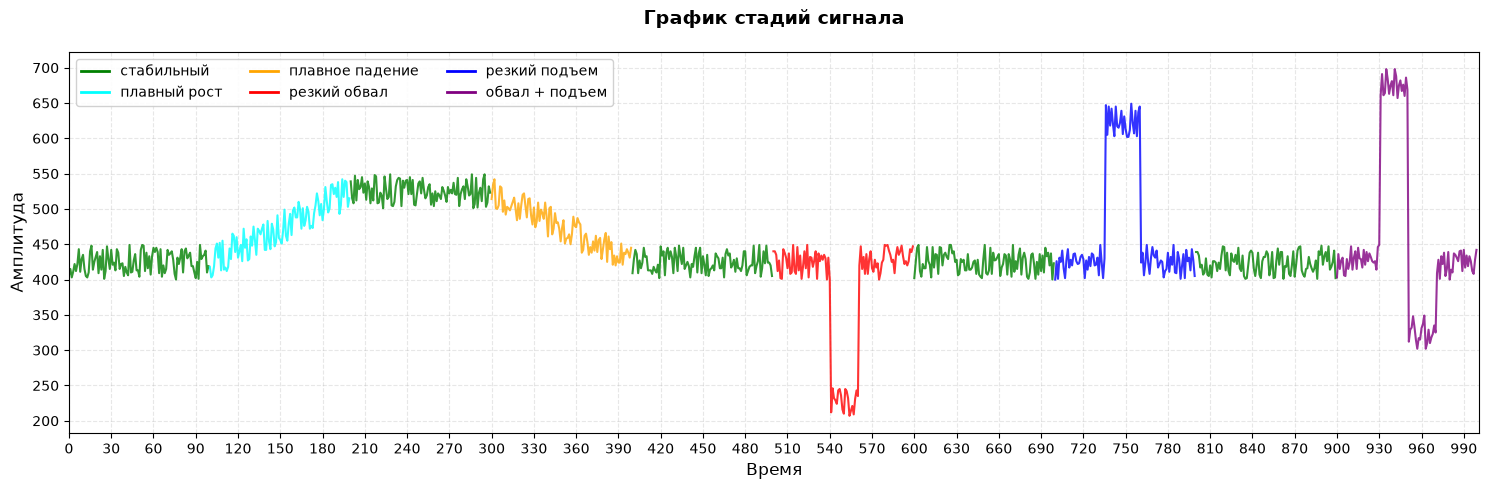

In [85]:
plt.figure(figsize=(15, 5))

for i in range(0, len(data) - 1, SEGMENT_LENGTH):
    segment = data.iloc[i:i+SEGMENT_LENGTH]
    pred_class = y_pred[i//SEGMENT_LENGTH]
    color = colors.get(pred_class, 'black')
    plt.plot(segment['t'], segment['a'], color=color, linewidth=1.5, alpha=0.8)

plt.title('График стадий сигнала', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

legend = [Line2D([0], [0], color=colors[k], label=class_names[k], linewidth=2) 
                   for k in sorted(colors.keys())]
plt.legend(handles=legend, loc='upper left', ncol=3, framealpha=0.9)

plt.xlim(0, len(data))
plt.xticks(np.arange(0, len(data)+1, 30))
plt.yticks(np.arange(200, 750, 50))

plt.tight_layout()
plt.show()

Круговая диаграмма

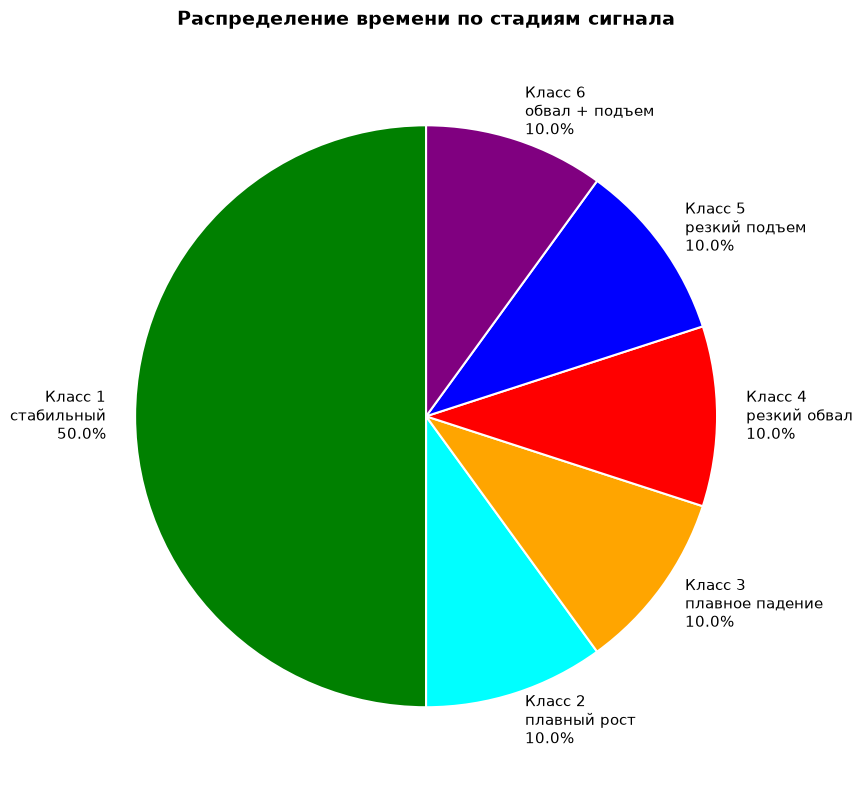

In [86]:
class_counts = {}
for pred_class in y_pred:
    class_counts[pred_class] = class_counts.get(pred_class, 0) + 1

class_counts = dict(sorted(class_counts.items()))

labels = [f"Класс {k}\n{class_names[k]}" for k in class_counts.keys()]
sizes = [count * SEGMENT_LENGTH for count in class_counts.values()]
colors_list = [colors[k] for k in class_counts.keys()]

total = sum(sizes)
percentages = [(s/total)*100 for s in sizes]
labels_with_pct = [f"{labels[i]}\n{percentages[i]:.1f}%" for i in range(len(labels))]

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(sizes, labels=labels_with_pct, colors=colors_list,
                                    autopct='', startangle=90,
                                    textprops={'fontsize': 11},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Распределение времени по стадиям сигнала', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Проверка модели на больших данных (для этого сгенерирован файл, похожий на train_data.csv)

In [87]:
val_data = pd.read_csv('train_data.csv', names=['t', 'a', 'klass'])

TEST_SEGMENT_LENGTH = 100
val_segments = []
val_labels = []

for i in range(0, len(val_data) - TEST_SEGMENT_LENGTH + 1, TEST_SEGMENT_LENGTH):
    segment = val_data['a'].iloc[i:i+TEST_SEGMENT_LENGTH].values
    label = val_data['klass'].iloc[i]
    val_segments.append(segment)
    val_labels.append(label)

X_big = np.array([list(extract_features(seg).values()) for seg in test_segments])
y_big = np.array(test_labels)

X_big_scaled = scaler.transform(X_big)

y_pred_big = model.predict(X_big_scaled)
accuracy = np.mean(y_pred_big == y_big)
accuracy

np.float64(1.0)

# Реальные данные

Файл 1

In [88]:
# Считываем данные
df = pd.read_excel('НПС-1 МНА-2.xlsx', header=7)

time_col = df.iloc[:, 0]
vacuum_1_data = df.iloc[:, 1].values
vacuum_2_data = df.iloc[:, 2].values
vacuum_3_data = df.iloc[:, 3].values
vacuum_4_data = df.iloc[:, 4].values
vacuum_5_data = df.iloc[:, 5].values
vacuum_6_data = df.iloc[:, 6].values
vacuum_7_data = df.iloc[:, 7].values
vacuum_8_data = df.iloc[:, 8].values

In [89]:
SEGMENT_LENGTH_1 = 150
segments_1 = []
labels_1 = []

for i in range(0, len(vacuum_1_data) - TEST_SEGMENT_LENGTH + 1, TEST_SEGMENT_LENGTH):
    segment = vacuum_1_data[i:i+SEGMENT_LENGTH]
    segments_1.append(segment)

X_1 = np.array([list(extract_features(seg).values()) for seg in segments_1])

X_1_scaled = scaler.transform(X_1)

y_pred_1 = model.predict(X_1_scaled)

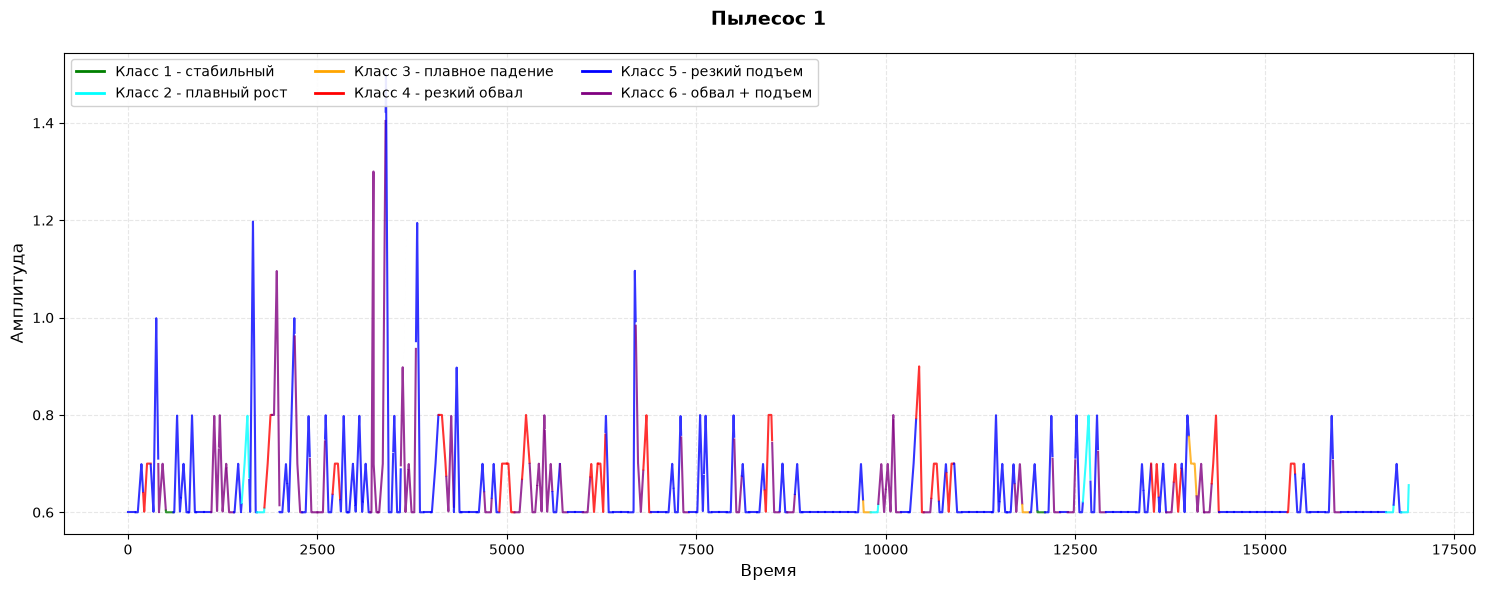

In [90]:
plt.figure(figsize=(15, 6))

for i, (segment, klass) in enumerate(zip(segments_1, y_pred_1)):
    start_idx = i * SEGMENT_LENGTH
    end_idx = start_idx + len(segment)
    time_segment = range(start_idx, end_idx)
    
    color = colors.get(klass, 'black')
    plt.plot(time_segment, segment, color=color, linewidth=1.5, alpha=0.8)

plt.title('Пылесос 1', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

legend_elements = [Line2D([0], [0], color=colors[k], label=f"Класс {k} - {class_names[k]}", linewidth=2) 
                   for k in sorted(colors.keys())]
plt.legend(handles=legend_elements, loc='upper left', ncol=3, framealpha=0.9)

plt.tight_layout()
plt.show()

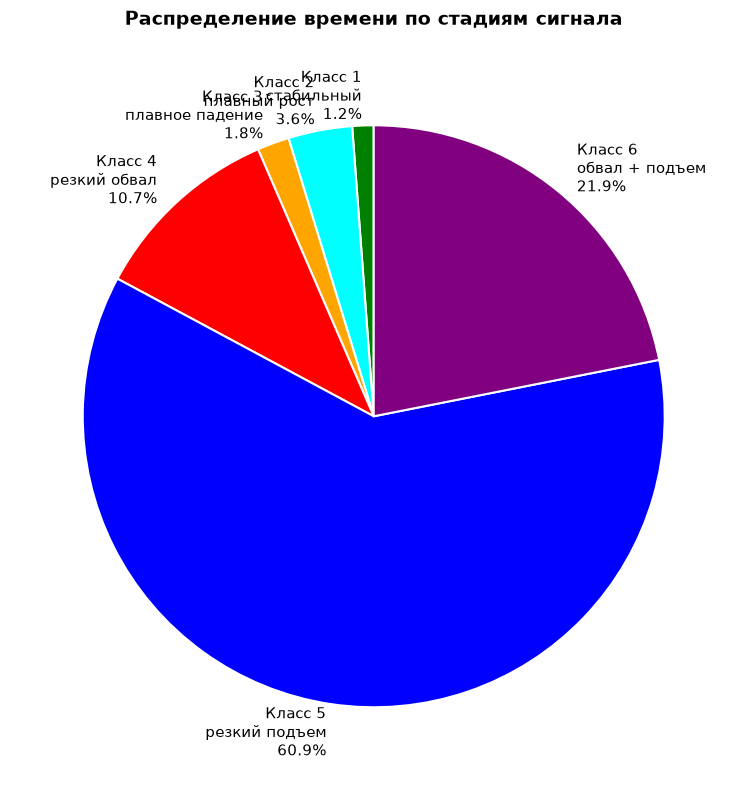

In [91]:
class_counts = {}
for pred_class in y_pred_1:
    class_counts[pred_class] = class_counts.get(pred_class, 0) + 1

class_counts = dict(sorted(class_counts.items()))

labels = [f"Класс {k}\n{class_names[k]}" for k in class_counts.keys()]
sizes = [count * SEGMENT_LENGTH for count in class_counts.values()]
colors_list = [colors[k] for k in class_counts.keys()]

total = sum(sizes)
percentages = [(s/total)*100 for s in sizes]
labels_with_pct = [f"{labels[i]}\n{percentages[i]:.1f}%" for i in range(len(labels))]

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(sizes, labels=labels_with_pct, colors=colors_list,
                                    autopct='', startangle=90,
                                    textprops={'fontsize': 11},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Распределение времени по стадиям сигнала', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Модель не вполне справляется с классификацией. Очень мало стабильных участков, даже в местах, где они должны были определится. Необходимо дообучение.

Модель и scaler сохранены
Модель и scaler загружены
Поиск точек изменения с помощью ruptures...
Найдено 87 сегментов
Точки разрыва: [140, 490, 615, 880, 1110, 1225, 1325, 1425, 1540, 1685, 1815, 1995, 2140, 2240, 2415, 2575, 2695, 2795, 2940, 3160, 3340, 3440, 3595, 3730, 3850, 4030, 4165, 4370, 4640, 4925, 5040, 5190, 5305, 5730, 6075, 6185, 6340, 6670, 6875, 7145, 7325, 7520, 7655, 7960, 8140, 8335, 8435, 8535, 8670, 8770, 8870, 9635, 9735, 9905, 10130, 10335, 10470, 10595, 10695, 10835, 10935, 11420, 11560, 11660, 11795, 11905, 12005, 12145, 12245, 12485, 12820, 13350, 13685, 13785, 13960, 14080, 14190, 14290, 14390, 15315, 15415, 15545, 15820, 15920, 16685, 16785, 16885, 16987]
Извлечены признаки из 87 сегментов
Классифицировано 87 сегментов


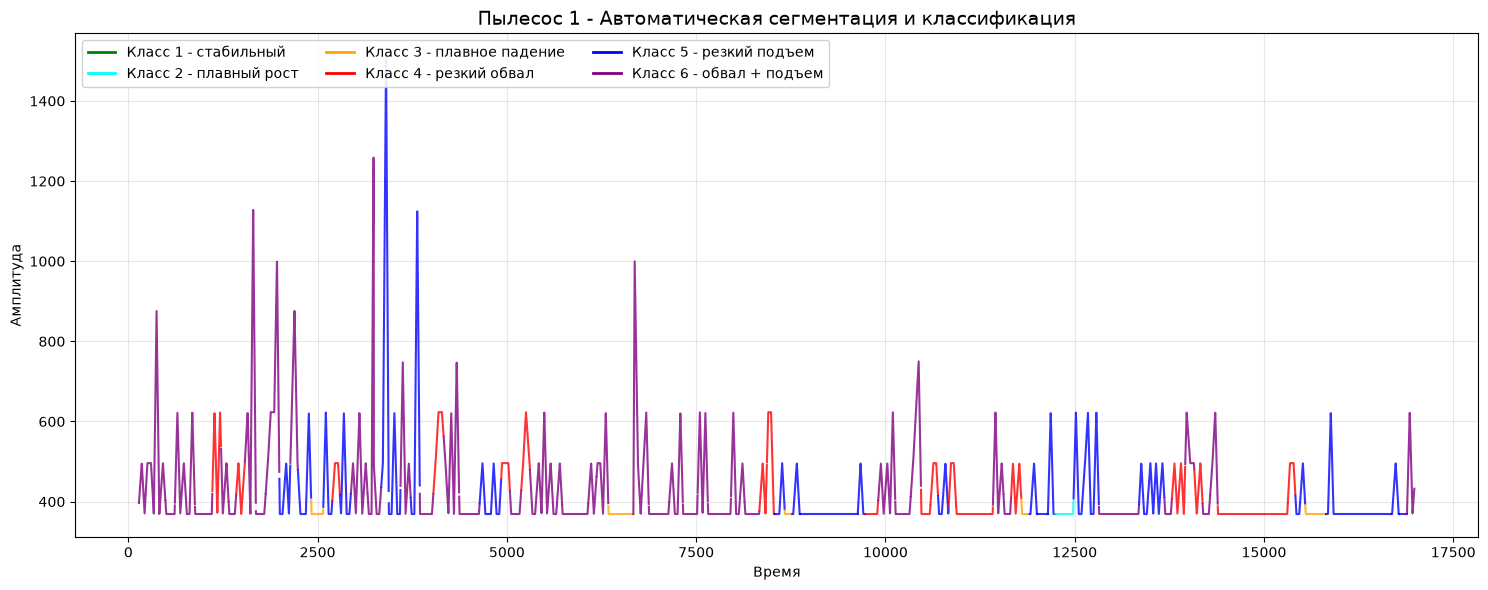


РАСПРЕДЕЛЕНИЕ КЛАССОВ
Класс 2 (плавный рост): 1 сегментов, 240 точек (1.1%)
Класс 3 (плавное падение): 5 сегментов, 975 точек (5.7%)
Класс 4 (резкий обвал): 18 сегментов, 3320 точек (20.7%)
Класс 5 (резкий подъем): 23 сегментов, 4690 точек (26.4%)
Класс 6 (обвал + подъем): 40 сегментов, 7622 точек (46.0%)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.fft import fft
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import ruptures as rpt

# ============================================
# ФУНКЦИЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ
# ============================================

def extract_features(segment):
    """Извлекает признаки, которые различают 6 классов."""
    N = len(segment)
    features = {}

    # Средний уровень сигнала в сегменте
    seg_mean = np.mean(segment)
    # СКО в сигнала в сегменте
    seg_std = np.std(segment) + 1e-10
    
    # Размах сигнала
    features['norm_range'] = (np.max(segment) - np.min(segment)) / seg_std
    
    # Максимальная производная
    derivative = np.diff(segment)
    features['max_derivative_norm'] = np.max(np.abs(derivative)) / seg_std
    
    # Стандартное отклонение нормализованного сигнала = 1 по определению,
    # но используем отношение max/min отклонения от среднего
    features['max_deviation_norm'] = max(
        np.max(segment) - seg_mean,
        seg_mean - np.min(segment)
    ) / seg_std
    
    # Доля точек, сильно отклоняющихся от среднего
    threshold_low = seg_mean - 1.5 * seg_std
    threshold_high = seg_mean + 1.5 * seg_std
    
    low_points = np.sum(segment < threshold_low) / N
    high_points = np.sum(segment > threshold_high) / N
    
    # Процент точек, сильно ниже среднего
    features['low_points_ratio'] = low_points
    # Процент точек, сильно выше среднего
    features['high_points_ratio'] = high_points
    # Процент "аномальных" точек
    features['extreme_points_ratio'] = low_points + high_points

    # Нормализуем сигнал с помощью Z-масштабирования
    seg_norm = (segment - seg_mean) / seg_std 
    
    yf = fft(seg_norm)
    spectrum = np.abs(yf[:N // 2 + 1])
    harmonics = np.arange(N // 2 + 1)
    max_harmonic = N // 2
    
    # Энергия в полосах
    low_threshold = max(1, int(max_harmonic * 0.1))
    mid_threshold = int(max_harmonic * 0.4)
    
    low_mask = (harmonics >= 1) & (harmonics < low_threshold)
    mid_mask = (harmonics >= low_threshold) & (harmonics < mid_threshold)
    high_mask = harmonics >= mid_threshold
    
    low_energy = np.sum(spectrum[low_mask] ** 2)
    mid_energy = np.sum(spectrum[mid_mask] ** 2)
    high_energy = np.sum(spectrum[high_mask] ** 2)
    total_energy = np.sum(spectrum[1:] ** 2) + 1e-10
    
    # Отношение ВЧ к НЧ
    features['high_to_low_ratio'] = (high_energy + 1e-10) / (low_energy + 1e-10)
    
    # Доля энергии на высоких частотах
    features['high_freq_ratio'] = high_energy / total_energy
    
    # Спектральный центроид
    features['spectral_centroid'] = np.sum(harmonics[1:] * spectrum[1:]) / total_energy / max_harmonic
    
    # Выделение огибающей для замера её наклона
    if N >= 21:
        envelope = savgol_filter(segment, window_length=21, polyorder=3)
    else:
        envelope = segment.copy()
    
    t = np.arange(N)
    slope = np.polyfit(t, envelope, 1)[0]
    features['envelope_slope_norm'] = slope / seg_std
    
    # Размах огибающей
    features['envelope_range_norm'] = (np.max(envelope) - np.min(envelope)) / seg_std

    # Ассиметрия спектра
    half = len(spectrum) // 2
    first_half_energy = np.sum(spectrum[1:half] ** 2)
    second_half_energy = np.sum(spectrum[half:] ** 2)
    features['spectrum_asymmetry'] = (first_half_energy - second_half_energy) / (total_energy + 1e-10)
    
    return features

# ============================================
# ШАГ 1: ОБУЧЕНИЕ МОДЕЛИ (один раз)
# ============================================

# Загрузите ваши обучающие данные
data = pd.read_csv('train_data_scaled.csv', header=None, names=['t', 'a', 'klass'])

# Разбейте на сегменты
SEGMENT_LENGTH = 100
train_segments = []
train_labels = []
for i in range(0, len(data) - SEGMENT_LENGTH + 1, SEGMENT_LENGTH):
    segment = data['a'].iloc[i:i+SEGMENT_LENGTH].values
    label = data['klass'].iloc[i]
    train_segments.append(segment)
    train_labels.append(label)

# Извлеките признаки
X = np.array([list(extract_features(seg).values()) for seg in train_segments])
y = np.array(train_labels)

# Создайте и обучите scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучите модель
model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=15, min_samples_leaf=2, class_weight='balanced')
model.fit(X_scaled, y)

# СОХРАНИТЕ модель и scaler
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Модель и scaler сохранены")

# ============================================
# ШАГ 2: ЗАГРУЗКА МОДЕЛИ И АВТОМАТИЧЕСКАЯ СЕГМЕНТАЦИЯ
# ============================================

# Загрузите сохранённые модель и scaler
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

print("Модель и scaler загружены")

# Загрузите данные пылесоса
df = pd.read_excel('НПС-1 МНА-2.xlsx', header=7)
signal = df.iloc[:, 1].dropna().values  # Первый пылесос
time_data = df.iloc[:, 0].dropna().values  # Время

# ============================================
# АВТОМАТИЧЕСКАЯ СЕГМЕНТАЦИЯ С rupture
# ============================================

print("Поиск точек изменения с помощью ruptures...")

# Алгоритм PELT для поиска точек разрыва
# Модель "rbf" хорошо работает с изменениями среднего и дисперсии
algo = rpt.Pelt(model="rbf", min_size=100).fit(signal)

# Подбираем штраф (penalty)
# Чем больше penalty, тем меньше сегментов
# Начните с 3.0, потом можно настроить
penalty = 12.0
breakpoints = algo.predict(pen=penalty)

print(f"Найдено {len(breakpoints)-1} сегментов")
print(f"Точки разрыва: {breakpoints}")

# ============================================
# ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ И КЛАССИФИКАЦИЯ
# ============================================

segments = []
segment_starts = []
segment_ends = []
features_list = []

for i in range(len(breakpoints) - 1):
    start = breakpoints[i]
    end = breakpoints[i + 1]
    seg = signal[start:end]
    
    feats = extract_features(seg)
    if feats is not None:
        segments.append(seg)
        segment_starts.append(start)
        segment_ends.append(end)
        features_list.append(feats)

print(f"Извлечены признаки из {len(segments)} сегментов")

# Классифицируем каждый сегмент
X_new = np.array([list(f.values()) for f in features_list])
X_new_scaled = scaler.transform(X_new)
segment_classes = model.predict(X_new_scaled).ravel()

print(f"Классифицировано {len(segment_classes)} сегментов")

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================

colors = {
    1: 'green',
    2: 'cyan',    
    3: 'orange',
    4: 'red',    
    5: 'blue',      
    6: 'purple'
}

class_names = {
    1: 'стабильный',
    2: 'плавный рост',
    3: 'плавное падение',
    4: 'резкий обвал',
    5: 'резкий подъем',
    6: 'обвал + подъем'
}

plt.figure(figsize=(15, 6))

# Рисуем каждый сегмент своим цветом
for seg, start, end, klass in zip(segments, segment_starts, segment_ends, segment_classes):
    time_range = range(start, end)
    color = colors.get(klass, 'black')
    plt.plot(time_range, seg, color=color, linewidth=1.5, alpha=0.8)

plt.title('Пылесос 1 - Автоматическая сегментация и классификация', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

legend_elements = [Line2D([0], [0], color=colors[k], label=f"Класс {k} - {class_names[k]}", linewidth=2) 
                   for k in sorted(colors.keys())]
plt.legend(handles=legend_elements, loc='upper left', ncol=3, framealpha=0.9)

plt.tight_layout()
plt.show()

# ============================================
# СТАТИСТИКА
# ============================================

from collections import Counter
class_counts = Counter(segment_classes)

print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ КЛАССОВ")
print("="*60)
for klass in sorted(class_counts.keys()):
    count = class_counts[klass]
    total_length = sum([segment_ends[i] - segment_starts[i] 
                        for i in range(len(segments)) if segment_classes[i] == klass])
    pct = (count / len(segments)) * 100
    print(f"Класс {klass} ({class_names[klass]}): {count} сегментов, {total_length} точек ({pct:.1f}%)")